## Данные

In [1]:
# Установка библиотек
import subprocess, sys
for pkg in ['requests', 'plotly']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [2]:
import requests
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Цвета для графиков
BLUE       = '#0055A5'
ACCENT     = '#E8702A'
BG_COLOR   = '#FFFFFF'
PLOT_BG    = '#F5F7FA'
FONT_COLOR = '#333333'
GRID_COLOR = '#D0D7E3'

In [4]:
def base_layout(title, height=500, margin=None, legend=None):
    m = margin or dict(l=160, r=40, t=90, b=80)
    lo = dict(
        title=dict(text=title, font=dict(size=16, color=BLUE,
                   family='Arial'), x=0.5, xanchor='center'),
        plot_bgcolor=PLOT_BG, paper_bgcolor=BG_COLOR,
        font=dict(family='Arial', size=12, color=FONT_COLOR),
        xaxis=dict(gridcolor=GRID_COLOR, zeroline=False),
        yaxis=dict(gridcolor=GRID_COLOR, zeroline=False),
        height=height, margin=m,
    )
    if legend is not None:
        lo['legend'] = legend
    return lo

def hbar(x_vals, y_labels, colors, text_vals=None, text_suffix=''):
    """Горизонтальная барная диаграмма (Plotly Bar, orientation=h)."""
    txt = text_vals if text_vals is not None else x_vals
    return go.Bar(
        x=x_vals, y=y_labels, orientation='h',
        marker_color=colors,
        text=[f'{v}{text_suffix}' for v in txt],
        textposition='outside', cliponaxis=False,
        hovertemplate='%{y}: %{x}<extra></extra>'
    )

In [5]:
# Загрузка данных
BGS_URL = 'https://ogcapi.bgs.ac.uk/collections/world-mineral-statistics/items'

# Перевод единиц в тонны
UNIT_TO_TONNES = {
    'tonnes': 1.0,
    'tonnes (metric)': 1.0,          # главный фикс: 1958 записей
    'tonnes (metal content)': 1.0,   # никель, медь: 337 записей
    'tonnes (al2o3 content)': 1.0,   # бокситы
    'tonnes (k2o content)': 1.0,     # калий
    'thousand tonnes': 1_000.0,
    'million tonnes': 1_000_000.0,
    'kilograms': 0.001,
    'kilograms (metal content)': 0.001,
    'kg': 0.001,
    'kt': 1_000.0,
    'mt': 1_000_000.0,
}

def fetch_bgs_production(target_year=None):
    """
    Загружает данные производства из BGS OGC-API Features.
    Если год не задан, определяет последний доступный год автоматически.
    """
    # Шаг 1: определяем последний доступный год
    if target_year is None:
        r = requests.get(BGS_URL, params={
            'f': 'json', 'limit': 20,
            'filter': 'bgs_statistic_type_trans = "Production"',
            'sortby': '-year'
        }, timeout=30)
        feats = r.json().get('features', [])
        years_found = sorted(
            set(int(f['properties']['year'][:4]) for f in feats),
            reverse=True
        )
        target_year = years_found[0] if years_found else 2023
        print(f"Последний доступный год в BGS: {target_year}")

    print(f"Загрузка данных BGS за {target_year} г.")
    all_features = []
    offset = 0
    limit = 5000

    while True:
        r = requests.get(BGS_URL, params={
            'f': 'json', 'limit': limit, 'offset': offset,
            'filter': (f'bgs_statistic_type_trans = "Production" '
                       f'AND year = "{target_year}-01-01"')
        }, timeout=90)

        data = r.json()
        features = data.get('features', [])
        all_features.extend(features)
        print(f"Получено: {len(all_features)} записей", end='\r')

        if len(features) < limit:
            break
        offset += limit

    print(f"\nВсего записей: {len(all_features)}")
    return all_features, target_year

raw_features, DATA_YEAR = fetch_bgs_production()

Последний доступный год в BGS: 2024
Загрузка данных BGS за 2024 г.
Получено: 2706 записей
Всего записей: 2706


In [6]:
# Обработка данных: нормализация единиц, агрегация по странам

records = []
for feat in raw_features:
    p = feat['properties']
    unit = (p.get('units') or '').lower().strip()
    qty  = p.get('quantity') or 0.0
    mult = UNIT_TO_TONNES.get(unit)
    if mult is None or qty <= 0:
        continue
    records.append({
        'country':    (p.get('country_trans') or ''),
        'iso3':       (p.get('country_iso3_code') or ''),
        'commodity':  (p.get('bgs_commodity_trans') or '').lower(),
        'erml_group': (p.get('erml_group') or ''),
        'qty_t':      qty * mult,
    })

df = pd.DataFrame(records)

# Тонны в миллионы тонн
df['qty_mt'] = df['qty_t'] / 1_000_000

# Суммарный объём добычи по странам
country_total = (df.groupby('country')['qty_mt'].sum()
                 .reset_index()
                 .rename(columns={'qty_mt': 'prod_mt'})
                 .sort_values('prod_mt', ascending=False)
                 .reset_index(drop=True))

print(f"Стран в датасете: {df['country'].nunique()}")
print(f"\nТОП-10 стран по объёму добычи ({DATA_YEAR} г., млн т):")
print(country_total.head(10).to_string(index=False))

TOP10 = country_total.head(10)['country'].tolist()
RUSSIA_NAMES = ['Russia', 'Russian Federation']

Стран в датасете: 173

ТОП-10 стран по объёму добычи (2024 г., млн т):
     country     prod_mt
       China 8428.830342
       India 1718.995458
   Australia 1600.001487
         USA 1586.670623
      Russia 1239.820135
   Indonesia  909.797058
      Brazil  761.795022
     Germany  602.672800
Saudi Arabia  552.815419
      Canada  425.877087


In [7]:
# ДИАГНОСТИКА: какие единицы приходят из BGS?
all_units = {}
for feat in raw_features:
    p = feat['properties']
    unit = (p.get('units') or '').strip()
    qty  = p.get('quantity') or 0
    comm = (p.get('bgs_commodity_trans') or '')
    if unit not in all_units:
        all_units[unit] = {'n': 0, 'example': comm, 'total': 0}
    all_units[unit]['n'] += 1
    all_units[unit]['total'] += qty

print(f"{'✓/✗':<4} {'Единица':<40} {'Кол-во':<8} {'Пример товара'}")
print('-'*90)
for unit, info in sorted(all_units.items(), key=lambda x: -x[1]['total']):
    matched = unit.lower().strip() in UNIT_TO_TONNES
    mark = '✓' if matched else '✗'
    print(f"{mark:<4} {unit!r:<40} {info['n']:<8} {info['example'][:35]}")

✓/✗  Единица                                  Кол-во   Пример товара
------------------------------------------------------------------------------------------
✓    'tonnes (metric)'                        1958     bentonite and fuller's earth
✓    'kilograms'                              132      gold, mine
✓    'tonnes (Al2O3 content)'                 25       alumina
✗    'Carats'                                 27       diamond
✓    'tonnes (K2O content)'                   14       potash
✓    'tonnes (metal content)'                 337      nickel, mine
✓    'kilograms (metal content)'              112      silver, mine
✗    'million cubic metres'                   99       natural gas
✓    'thousand tonnes'                        2        


## Блок 1. Россия на карте мировой добычи

### 1.1. Топ-30 стран по объёму горнодобывающего производства (2024 г.)

In [8]:
RU_COUNTRIES = {
    'China': 'Китай', 'Australia': 'Австралия', 'Brazil': 'Бразилия',
    'India': 'Индия', 'Russia': 'Россия', 'Russian Federation': 'Россия',
    'Iran': 'Иран', 'Canada': 'Канада', 'USA': 'США',
    'United States': 'США', 'United States of America': 'США',
    'South Africa': 'ЮАР', 'Japan': 'Япония', 'Chile': 'Чили',
    'Congo, Democratic Republic': 'ДРК', 'Peru': 'Перу', 'Zambia': 'Замбия',
    'Indonesia': 'Индонезия', 'Ghana': 'Гана', 'Kazakhstan': 'Казахстан',
    'Uzbekistan': 'Узбекистан', 'Mexico': 'Мексика', 'Niger': 'Нигер',
    'Namibia': 'Намибия', 'Mongolia': 'Монголия', 'Bolivia': 'Боливия',
    'Argentina': 'Аргентина', 'Philippines': 'Филиппины',
    'Myanmar': 'Мьянма', 'Sweden': 'Швеция', 'Finland': 'Финляндия',
    'Germany': 'Германия', 'Norway': 'Норвегия', 'Ukraine': 'Украина',
    'New Caledonia': 'Нов. Каледония', 'Saudi Arabia': 'Саудовская Аравия',
    'North Korea': 'КНДР', 'Colombia': 'Колумбия', 'Pakistan': 'Пакистан',
    'United Kingdom': 'Великобритания', 'Czech Republic': 'Чехия',
    'Democratic Republic of the Congo': 'ДРК',
    'Madagascar': 'Мадагаскар', 'Malaysia': 'Малайзия', 'Vietnam': 'Вьетнам',
    'Poland': 'Польша',
    'Turkey': 'Турция',
    'France': 'Франция',
    'Spain': 'Испания',
    'Iraq': 'Ирак',
    'United Arab Emirates': 'ОАЭ',
    'Romania': 'Румыния',
    'Guinea': 'Гвинея',
    'Kuwait': 'Кувейт',
    'Korea (Rep. of)': 'Южная Корея',
    'Korea, Republic of': 'Южная Корея',
    'South Korea': 'Южная Корея',
    'Italy': 'Италия',
    'Iran (Islamic Republic of)': 'Иран',
}

In [9]:
top30 = country_total.head(30).sort_values('prod_mt', ascending=True)

# Перевод на русский (RU_COUNTRIES уже определён выше)
top30_ru = top30['country'].map(lambda c: RU_COUNTRIES.get(c, c))

colors30 = [ACCENT if c in RUSSIA_NAMES else BLUE
            for c in top30['country']]

fig1 = go.Figure(hbar(
    x_vals   = top30['prod_mt'].round(1).tolist(),
    y_labels = top30_ru.tolist(),
    colors   = colors30,
    text_vals= [f'{v:.0f}' for v in top30['prod_mt']],
    text_suffix=' млн т',
))

layout1 = base_layout(
    f'Топ-30 стран по объёму добычи полезных ископаемых ({DATA_YEAR} г.)<br>',
    height=780, margin=dict(l=175, r=120, t=110, b=60)
)
layout1['xaxis']['title'] = 'Суммарный объём добычи, млн т'
layout1['margin'] = dict(l=175, r=120, t=110, b=100)
fig1.update_layout(**layout1)

fig1.add_annotation(
    text=f'<b>Источник:</b> British Geological Survey (BGS), World Mineral Production {DATA_YEAR}. '
         'OGC API: ogcapi.bgs.ac.uk. '
         'Совокупный объём рассчитан по товарным группам, представленным в единицах массы.',
    xref='paper', yref='paper', x=0.5, y=-0.11,
    showarrow=False, font=dict(size=8, color='#666666'), xanchor='center'
)

fig1.show()

**Что показывает график:**
Рейтинг топ-30 стран мира по совокупному объёму горнодобывающего производства в 2024 г. (млн т, все виды полезных ископаемых в единицах массы). Россия выделена оранжевым.

**Ключевые выводы:**
- Россия занимает 5 место в мире с объёмом добычи 1 239,8 млн т (2024 г.)
- Лидер - Китай (8 428 млн т), опережает Россию в 6,8 раза
- Россия входит в тройку крупнейших несырьевых (non-China/India) горнодобывающих держав наряду с Австралией и США
- Позиция подтверждает стратегическое значение российской горнодобывающей отрасли в глобальном масштабе

**Источник:** [British Geological Survey (BGS), World Mineral Production 2024](https://www.bgs.ac.uk/mineralsuk/statistics/worldStatistics.html) · [OGC API](https://ogcapi.bgs.ac.uk/collections/world-mineral-statistics/items) Совокупный объём рассчитан по товарным группам в единицах массы (исключены баррели нефти, кубометры газа, каратов алмазов).

### 1.2. Топ-10 по ключевым видам стратегического сырья (2024 г.)

In [10]:
print(country_total.head(10).to_string(index=False))

     country     prod_mt
       China 8428.830342
       India 1718.995458
   Australia 1600.001487
         USA 1586.670623
      Russia 1239.820135
   Indonesia  909.797058
      Brazil  761.795022
     Germany  602.672800
Saudi Arabia  552.815419
      Canada  425.877087


In [11]:
STRATEGIC = {
    'Уголь':  lambda d: d['commodity'].str.lower().str.contains('coal', na=False),
    'Железо': lambda d: d['commodity'].str.lower().str.contains('iron', na=False),
    'Медь':   lambda d: d['erml_group'].str.lower().str.contains('copper', na=False),
    'Золото': lambda d: d['erml_group'].str.lower().str.contains('gold', na=False),
    'Никель': lambda d: d['erml_group'].str.lower().str.contains('nickel', na=False),
    'Уран':   lambda d: d['commodity'].str.lower().str.contains('uranium', na=False),
    'РЗМ':    lambda d: (d['erml_group'].str.lower().str.contains('rare earth', na=False) |
                         d['commodity'].str.lower().str.contains('rare earth', na=False)),
}


fig2 = make_subplots(
    rows=4, cols=2,
    subplot_titles=list(STRATEGIC.keys()),
    horizontal_spacing=0.18,
    vertical_spacing=0.08,
)

for idx, (label, flt_fn) in enumerate(STRATEGIC.items()):
    row, col = divmod(idx, 2)
    subset = df[flt_fn(df)]
    top10_raw = (subset.groupby('country')['qty_mt'].sum()
                 .nlargest(10).sort_values(ascending=True))

    if top10_raw.empty:
        continue

    # Авто-выбор единицы отображения
    max_val = top10_raw.values.max()
    if max_val < 0.01:
        display_vals = top10_raw.values * 1_000_000
        unit = 'т'
    elif max_val < 1:
        display_vals = top10_raw.values * 1_000
        unit = 'тыс. т'
    else:
        display_vals = top10_raw.values
        unit = 'млн т'

    ru_labels = [RU_COUNTRIES.get(c, c) for c in top10_raw.index]
    clrs = [ACCENT if RU_COUNTRIES.get(c, c) == 'Россия' else BLUE
            for c in top10_raw.index]

    fmt = [f'{v:,.0f}' if v >= 100 else (f'{v:.1f}' if v >= 1 else f'{v:.2f}')
           for v in display_vals]

    fig2.add_trace(
        go.Bar(x=display_vals, y=ru_labels, orientation='h',
               marker_color=clrs,
               text=[f'{f} {unit}' for f in fmt],
               textposition='outside', cliponaxis=False,
               showlegend=False,
               hovertemplate=f'%{{y}}: %{{x:,.1f}} {unit}<extra></extra>'),
        row=row+1, col=col+1
    )

fig2.update_layout(
    title=dict(
        text=(f'Топ-10 стран по стратегическим и критическим видам сырья ({DATA_YEAR} г.)<br>'
              '<span style="font-size:12px;color:#666">Объём добычи · '
              'Источник: <a href="https://www.bgs.ac.uk/mineralsuk/statistics/worldStatistics.html">BGS World Mineral Production</a> · Оранжевым — Россия</span>'),
        font=dict(size=16, color=BLUE, family='Arial'),
        x=0.5, xanchor='center'),
    plot_bgcolor=PLOT_BG, paper_bgcolor=BG_COLOR,
    font=dict(family='Arial', size=10, color=FONT_COLOR),
    height=1400, margin=dict(l=130, r=90, t=110, b=60),
)
for ax in fig2.layout:
    if ax.startswith('xaxis'):
        fig2.layout[ax].update(gridcolor=GRID_COLOR, zeroline=False, tickformat=',')
    if ax.startswith('yaxis'):
        fig2.layout[ax].update(gridcolor=GRID_COLOR, zeroline=False)

fig2.show()

**Что показывают графики:**
Топ-10 стран по добыче 7 стратегических видов сырья: уголь, железо, медь, золото, никель, уран, РЗМ (редкоземельные металлы).

**Ключевые выводы:**
- **Уголь:** Китай и Индия вместе обеспечивают более 70% мировой добычи, Россия входит в пятёрку лидеров
- **Никель:** Индонезия - лидер, Россия (Норникель) удерживает позиции в мировой пятёрке
- **Золото:** Россия входит в тройку крупнейших производителей
- **Уран:** Казахстан - мировой лидер, Россия присутствует в нескольких крупных юрисдикциях через Росатом
- **РЗМ:** Китай контролирует >60% мировой добычи, что является критической концентрацией для глобальных цепочек поставок

**Источник:** [British Geological Survey (BGS), World Mineral Production 2024](https://www.bgs.ac.uk/mineralsuk/statistics/worldStatistics.html) · [OGC API](https://ogcapi.bgs.ac.uk/collections/world-mineral-statistics/items)

### 1.3. Доля топ-10 стран в мировой добыче по видам сырья (2024 г.)

In [12]:
STRATEGIC_HEAT = {
    'Уголь':  lambda d: d['commodity'].str.lower().str.contains('coal', na=False),
    'Железо': lambda d: d['commodity'].str.lower().str.contains('iron', na=False),
    'Медь':   lambda d: d['erml_group'].str.lower().str.contains('copper', na=False),
    'Золото': lambda d: d['erml_group'].str.lower().str.contains('gold', na=False),
    'Никель': lambda d: d['erml_group'].str.lower().str.contains('nickel', na=False),
    'Уран':   lambda d: d['commodity'].str.lower().str.contains('uranium', na=False),
    'РЗМ':    lambda d: (d['erml_group'].str.lower().str.contains('rare earth', na=False) |
                         d['commodity'].str.lower().str.contains('rare earth', na=False)),
}

# Доля топ-10 стран в мировом производстве каждого вида
heat_data = {}
for label, flt_fn in STRATEGIC_HEAT.items():
    subset = df[flt_fn(df)]
    world_total = subset['qty_mt'].sum()
    if world_total == 0:
        continue
    top10_shares = (subset[subset['country'].isin(TOP10)]
                    .groupby('country')['qty_mt'].sum()
                    / world_total * 100)
    heat_data[label] = top10_shares

heat_df = pd.DataFrame(heat_data).reindex(TOP10).fillna(0)

# Названия стран на русский
heat_df.index = [RU_COUNTRIES.get(c, c) for c in heat_df.index]


ru_idx = [i for i, c in enumerate(heat_df.index) if c == 'Россия']
other_idx = [i for i, c in enumerate(heat_df.index) if c != 'Россия']
heat_df = heat_df.iloc[ru_idx + other_idx]

fig3 = go.Figure(go.Heatmap(
    z=heat_df.values,
    x=heat_df.columns.tolist(),
    y=heat_df.index.tolist(),
    colorscale=[
        [0.0, '#EEF2F8'],
        [0.3, '#6FA3D8'],
        [0.6, '#0055A5'],
        [1.0, '#003070'],
    ],
    zmin=0, zmax=60,
    text=[[f'{v:.1f}%' if v > 0.5 else ('—' if v == 0 else f'{v:.1f}%')
           for v in row] for row in heat_df.values],
    texttemplate='%{text}',
    hovertemplate='%{y} · %{x}: %{z:.1f}%<extra></extra>',
    showscale=True,
    colorbar=dict(title='Доля, %', thickness=14, len=0.9),
))

# Рамка вокруг строки России
for i, country in enumerate(heat_df.index):
    if country == 'Россия':
        fig3.add_shape(type='rect',
            x0=-0.5, x1=len(heat_df.columns)-0.5,
            y0=i-0.5, y1=i+0.5,
            line=dict(color=ACCENT, width=2.5))

fig3.update_layout(**base_layout(
    f'Доля топ-10 стран в мировой добыче по видам сырья ({DATA_YEAR} г.)<br>'
    '<span style="font-size:12px;color:#666">% от мирового объёма добычи · '
    f'Источник: BGS World Mineral Production {DATA_YEAR}</span>',
    height=420,
    margin=dict(l=130, r=80, t=110, b=60),
))
fig3.show()

**Что показывает тепловая карта:**
Доля топ-10 горнодобывающих стран в мировом производстве по каждому из 7 стратегических видов сырья. Чем темнее ячейка, тем выше доля страны в мировой добыче.

**Ключевые выводы:**
- Россия занимает значимые позиции по углю, никелю и золоту, однако её доля в РЗМ минимальна
- Китай доминирует в РЗМ и угле, стратегическая зависимость мирового рынка от одной страны
- По урану в тепловую карту входят иные страны (Казахстан, Канада, Намибия), топ-10 по общей добыче не совпадает с лидерами уранодобычи
- Диверсификация сырьевого портфеля России (уголь, золото, никель, уран) снижает риск зависимости от одного рынка

**Источник:** [British Geological Survey (BGS), World Mineral Production 2024](https://www.bgs.ac.uk/mineralsuk/statistics/worldStatistics.html) · [OGC API](https://ogcapi.bgs.ac.uk/collections/world-mineral-statistics/items)

## Блок 2. Финансовые показатели ведущих горнодобывающих компаний мира (2025 г.)

### 2.1. Выручка ведущих горнодобывающих компаний (2025 г.)

In [13]:
ROSATOM_NEDRA_COLOR = '#27AE60'

def comp_color(name):
    if name == 'АО «Росатом Недра»\n(Россия)':
        return ROSATOM_NEDRA_COLOR
    elif name == 'Норильский Никель\n(Россия)':
        return ACCENT
    else:
        return BLUE

COMP_NAMES = [
    'АО «Росатом Недра»\n(Россия)',
    'PT Bukit Asam\n(Индонезия)',
    'K+S AG\n(Германия)',
    "Ma'aden\n(Саудовская Аравия)",
    'Agnico Eagle\n(Канада)',
    'Норильский Никель\n(Россия)',
    'Coal India\n(Индия)',
    'Newmont\n(США)',
    'Vale\n(Бразилия)',
    'Zijin Mining\n(Китай)',
    'BHP\n(Австралия)',
]

# Выручка 2025
COMP_REV = [0.96, 2.6, 4.0, 10.3, 11.9, 13.8, 16.8, 22.7, 38.4, 49.7, 51.3]

# EBITDA 2025
COMP_EB  = [0.25, 0.31, 0.67,  4.3,  8.1,  5.7,  6.1, 13.5, 15.5, 14.3, 26.0]

# CAPEX 2025
COMP_CX  = [0.33, 0.20, 0.60,  1.8,  2.1,  2.6,  2.6,  3.0,  5.5,  6.0,  9.8]

# Список цветов для каждой компании
comp_clrs = [comp_color(n) for n in COMP_NAMES]

Среднегодовой курс ЦБ РФ 2025, kursvaliut.ru

In [14]:
# 2.1 Выручка компаний
fig_cr = go.Figure(hbar(COMP_REV, COMP_NAMES, comp_clrs, text_suffix=' $млрд'))
lo_cr = base_layout(
    'Выручка ведущих горнодобывающих компаний (2025 г.)<br>'
    '<span style="font-size:12px">Источник: Годовые отчёты компаний 2025 г. · '
    'Отбор: PwC Mine 2026</span>',
    height=560, margin=dict(l=200, r=100, t=100, b=130)
)
lo_cr['xaxis']['title'] = 'Выручка, $млрд'
fig_cr.update_layout(**lo_cr)
fig_cr.add_annotation(
    text=(
        'АО «Росатом Недра» - внутренняя отчётность 2025 г., конвертация по курсу ЦБ РФ 83.21 руб/$. '
        'Coal India - FY2024-25, INR/USD 85.3. K+S AG - EUR/USD 1.09. '
        'PT Bukit Asam - IDR/USD 16,300. BHP - FY2025 (июль 2024-июнь 2025). '
        'Agnico Eagle - PwC Mine 2026 #6. Newmont - PwC Mine 2026 #5.'
    ),
    xref='paper', yref='paper', x=0.5, y=-0.21,
    showarrow=False, font=dict(size=8, color='#666666'), xanchor='center'
)
fig_cr.show()

**Что показывает график:** Рейтинг ведущих горнодобывающих компаний мира по выручке за 2025 г. (в млрд долл. США). Позволяет оценить масштаб бизнеса и рыночную позицию АО «Росатом Недра» относительно глобальных лидеров отрасли.

**Ключевые выводы:**
Тройка лидеров по выручке: BHP (Австралия) - 51,3 млрд, Zijin Mining (Китай) - 49,7 млрд, Vale (Бразилия) - 38,4 млрд. АО «Росатом Недра» с выручкой $0,96 млрд замыкает рейтинг, уступая лидеру более чем в 50 раз. Несмотря на значительный рост выручки в рублях (+275% с 2015 г.), в долларовом эквиваленте компания остаётся небольшим игроком на фоне глобальных конкурентов.

### 2.2. EBITDA ведущих горнодобывающих компаний (2025 г.)

In [15]:
eb_order = sorted(zip(COMP_EB, COMP_NAMES), key=lambda x: x[0])
eb_cv, eb_cn = zip(*eb_order)
eb_cc = [comp_color(c) for c in eb_cn]

fig_ceb = go.Figure(hbar(list(eb_cv), list(eb_cn), list(eb_cc), text_suffix=' $млрд'))
lo_ceb = base_layout(
    'EBITDA ведущих горнодобывающих компаний (2025 г.)<br>'
    '<span style="font-size:12px">Источник: Годовые отчёты компаний 2025 г.</span>',
    height=560, margin=dict(l=200, r=100, t=100, b=80)
)
lo_ceb['xaxis']['title'] = 'EBITDA, $млрд'
fig_ceb.update_layout(**lo_ceb)
fig_ceb.show()

**Что показывает график:** EBITDA (операционная прибыль до вычета амортизации) ведущих горнодобывающих компаний за 2025 г. - ключевой показатель операционной эффективности бизнеса.

**Ключевые выводы:**
Наибольшую операционную прибыль генерируют BHP (26,0 млрд), Vale (15,5 млрд) и Zijin Mining (14,3 млрд).
EBITDA АО «Росатом Недра» - 0,25 млрд, что соответствует уровню наименее крупных участников рейтинга.
Разрыв с лидером (BHP) составляет более 100 раз, что указывает на существенный потенциал роста операционной прибыльности.

### 2.3. CAPEX ведущих горнодобывающих компаний (2025 г.)

In [16]:
cx_order = sorted(zip(COMP_CX, COMP_NAMES), key=lambda x: x[0])
cx_cv, cx_cn = zip(*cx_order)
cx_cc = [comp_color(c) for c in cx_cn]

fig_ccx = go.Figure(hbar(list(cx_cv), list(cx_cn), list(cx_cc), text_suffix=' $млрд'))
lo_ccx = base_layout(
    'Капитальные затраты (CAPEX) ведущих горнодобывающих компаний (2025 г.)<br>'
    '<span style="font-size:12px">Источник: Годовые отчёты компаний 2025 г.</span>',
    height=560, margin=dict(l=200, r=100, t=100, b=80)
)
lo_ccx['xaxis']['title'] = 'CAPEX, $млрд'
fig_ccx.update_layout(**lo_ccx)
fig_ccx.show()

**Что показывает график:** Капитальные затраты (CAPEX) ведущих горнодобывающих компаний в 2025 г. — объём инвестиций в развитие и поддержание производственных активов.

**Ключевые выводы:**
Крупнейшие инвесторы в инфраструктуру: BHP (9,8 млрд), Vale (5,5 млрд), Zijin Mining (6,0 млрд).
АО «Росатом Недра» вложила 0,33 млрд - относительно высокий показатель для компании данного масштаба.
Высокая доля CAPEX в структуре затрат Росатом Недра свидетельствует об активной фазе развития и расширения производственной базы.

### 2.4. CAPEX/EBITDA ведущих горнодобывающих компаний (2025 г.)

In [17]:
import operator
cx_eb_ratio = [round(eb/cx*100, 1) for cx, eb in zip(COMP_CX, COMP_EB)]
ratio_order = sorted(zip(cx_eb_ratio, COMP_NAMES), key=operator.itemgetter(0))
r_vals, r_names = zip(*ratio_order)
r_clrs = [comp_color(c) for c in r_names]

fig_ratio = go.Figure(hbar(list(r_vals), list(r_names), list(r_clrs), text_suffix='%'))
lo_r = base_layout(
    'Коэффициент EBITDA/CAPEX: эффективность капитальных вложений (2025 г.)<br>'
    '<span style="font-size:12px">EBITDA ÷ CAPEX × 100% · Источник: Годовые отчёты 2025 г. · <a href="https://www.pwc.com/gx/en/energy-utilities-mining/publications/mine.html">PwC Mine 2026</a></span>',
    height=560, margin=dict(l=200, r=80, t=100, b=80)
)
lo_r['xaxis']['title'] = 'EBITDA / CAPEX, %'
fig_ratio.update_layout(**lo_r)
fig_ratio.show()

**Что показывает график:** Коэффициент EBITDA/CAPEX - соотношение операционной прибыли к капитальным вложениям. Чем выше значение, тем эффективнее компания генерирует прибыль на каждый вложенный в развитие доллар.

**Ключевые выводы:**
Наиболее эффективны по данному показателю Coal India (238%), Zijin Mining (238%) и Agnico Eagle (386%).
АО «Росатом Недра» демонстрирует коэффициент ниже 100%, что означает: CAPEX превышает EBITDA, компания инвестирует активнее, чем зарабатывает операционной прибыли.
Это характерно для компаний в фазе активного роста и расширения, когда инвестиции опережают текущую доходность.

### 2.5. EBITDA-маржа ведущих горнодобывающих компаний (2025 г.)

In [18]:
eb_margin = [round(eb/rev*100, 1) for eb, rev in zip(COMP_EB, COMP_REV)]
marg_order = sorted(zip(eb_margin, COMP_NAMES), key=operator.itemgetter(0))
m_vals, m_names = zip(*marg_order)
m_clrs = [comp_color(c) for c in m_names]

fig_marg = go.Figure(hbar(list(m_vals), list(m_names), list(m_clrs), text_suffix='%'))
lo_m = base_layout(
    'EBITDA-маржа ведущих горнодобывающих компаний (2025 г.)<br>'
    '<span style="font-size:12px">EBITDA ÷ Выручка × 100% · Источник: Годовые отчёты 2025 г. · <a href="https://www.pwc.com/gx/en/energy-utilities-mining/publications/mine.html">PwC Mine 2026</a></span>',
    height=560, margin=dict(l=200, r=80, t=100, b=80)
)
lo_m['xaxis']['title'] = 'EBITDA-маржа, %'
fig_marg.update_layout(**lo_m)
fig_marg.show()

**Что показывает график:** EBITDA-маржа (EBITDA / Выручка × 100%) — показатель рентабельности, отражающий, какую долю выручки компания конвертирует в операционную прибыль.

**Ключевые выводы:**
Наиболее рентабельны Agnico Eagle (68,1%), Ma'aden (41,7%) и BHP (50,7%) — компании с высокой долей ценных металлов и эффективной структурой затрат. EBITDA-маржа АО «Росатом Недра» составляет 26,2%, что находится в нижней части рейтинга, однако соответствует среднеотраслевым значениям для диверсифицированных горнодобывающих компаний.
Рост маржи является одним из ключевых приоритетов для повышения инвестиционной привлекательности компании.

## Блок 3. Инвестиции в технологии и цифровизацию (2025 г.)

In [19]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Планы по инвестициям в цифровизацию (2026 г.)',
        'Статус внедрения цифровых технологий'
    )
)

# планы на 2026
labels_plans  = ['Снизить', 'Сохранить', 'Увеличить']
values_plans  = [27, 49, 24]
colors_plans  = ['#C0392B', '#95A5A6', BLUE]

fig.add_trace(go.Bar(
    x=labels_plans,
    y=values_plans,
    marker_color=colors_plans,
    text=[f'{v}%' for v in values_plans],
    textposition='outside',
    textfont=dict(size=13, color=FONT_COLOR),
    showlegend=False
), row=1, col=1)

# статус внедрения
labels_impl = ['Фрагментарно\nили тестово', 'Системное\nвнедрение']
values_impl = [81, 19]
colors_impl = ['#C0392B', BLUE]

fig.add_trace(go.Bar(
    x=labels_impl,
    y=values_impl,
    marker_color=colors_impl,
    text=[f'{v}%' for v in values_impl],
    textposition='outside',
    textfont=dict(size=13, color=FONT_COLOR),
    showlegend=False
), row=1, col=2)

fig.update_layout(
    title=dict(
        text='Цифровизация горнодобывающих компаний России',
        font=dict(size=16, color=FONT_COLOR, family='Arial'),
        x=0.5
    ),
    paper_bgcolor=BG_COLOR,
    plot_bgcolor=PLOT_BG,
    font=dict(color=FONT_COLOR, size=12, family='Arial'),
    height=500,
    margin=dict(t=100, b=130, l=60, r=40)
)

fig.update_yaxes(
    range=[0, 100],
    ticksuffix='%',
    gridcolor=GRID_COLOR
)

fig.add_annotation(
    text='56% российских горнодобывающих компаний тратят на цифровизацию менее 2% от выручки',
    xref='paper', yref='paper',
    x=0.5, y=-0.15,
    showarrow=False,
    font=dict(size=11, color='#C0392B'),
    xanchor='center'
)

fig.add_annotation(
    text='Источник: Kept и ГК «Цифра», апрель 2026 г.',
    xref='paper', yref='paper',
    x=0.5, y=-0.25,
    showarrow=False,
    font=dict(size=9, color='#888888'),
    xanchor='center'
)

fig.show()

**Что показывает:** уровень цифровизации и инвестиционные планы российских горнодобывающих компаний на 2026 год.

**Вывод:** Картина контрастирует с мировыми лидерами:
- **81%** компаний внедряют технологии лишь фрагментарно или в тестовом режиме
- **56%** тратят на цифровизацию менее 2% от выручки
- **27%** планируют снизить расходы на цифровые технологии в 2026 году
- Только 5% готовы инвестировать в новые масштабные инициативы

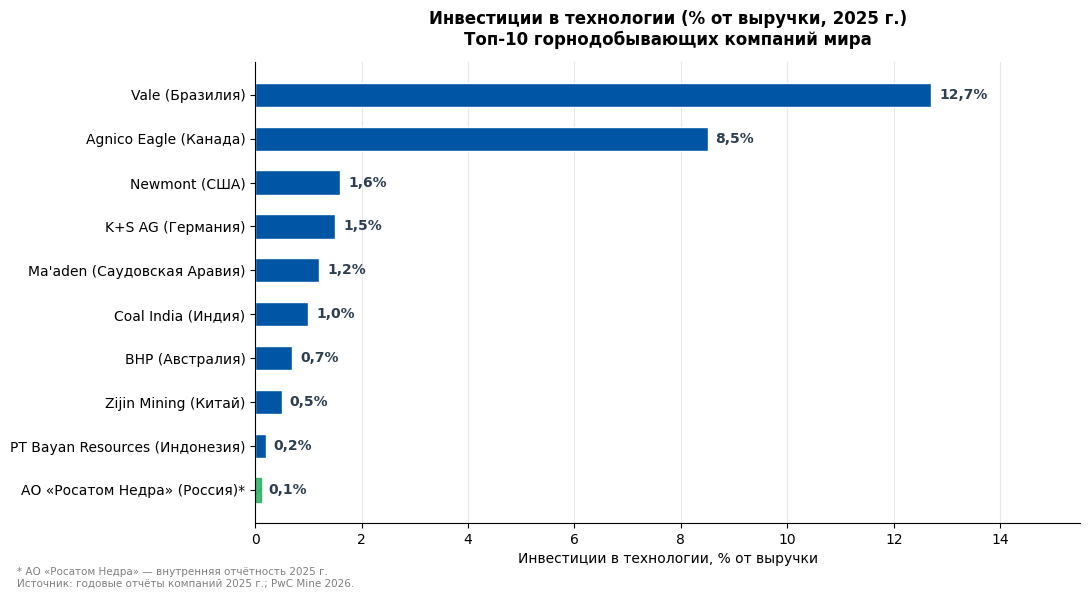

In [20]:
%matplotlib inline
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import matplotlib.pyplot as plt
from IPython.display import display

BLUE                = '#0055A5'
ACCENT              = '#E8702A'
ROSATOM_NEDRA_COLOR = '#27AE60'
LIGHT_GRAY          = '#BDC3C7'

companies = [
    'Vale (Бразилия)',
    'Agnico Eagle (Канада)',
    'Newmont (США)',
    'K+S AG (Германия)',
    "Ma'aden (Саудовская Аравия)",
    'Coal India (Индия)',
    'BHP (Австралия)',
    'Zijin Mining (Китай)',
    'PT Bayan Resources (Индонезия)',
    'АО «Росатом Недра» (Россия)*',
]
pct    = [12.7, 8.5, 1.6, 1.5, 1.2, 1.0, 0.7, 0.5, 0.2, 0.1]
labels = ['12,7%', '8,5%', '1,6%', '1,5%', '1,2%', '1,0%', '0,7%', '0,5%', '0,2%', '0,1%']
colors_bar = [BLUE, BLUE, BLUE, BLUE, BLUE, BLUE, BLUE, BLUE, BLUE, ROSATOM_NEDRA_COLOR]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(companies, pct, color=colors_bar,
               edgecolor='white', height=0.55, zorder=2)

# Штриховка для Росатом Недра
bars[-1].set_hatch('//')
bars[-1].set_edgecolor(ROSATOM_NEDRA_COLOR)
bars[-1].set_alpha(0.85)

for bar, lbl in zip(bars, labels):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            lbl, va='center', fontsize=10, fontweight='bold', color='#2C3E50')

ax.set_xlabel('Инвестиции в технологии, % от выручки', fontsize=10)
ax.set_title('Инвестиции в технологии (% от выручки, 2025 г.)\nТоп-10 горнодобывающих компаний мира',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 15.5)
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()

fig.text(0.02, 0.01,
    '* АО «Росатом Недра» — внутренняя отчётность 2025 г.\n'
    'Источник: годовые отчёты компаний 2025 г.; PwC Mine 2026.',
    fontsize=7.5, color='gray', va='bottom')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
fig.savefig('block3_v2.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close()

**Что показывает график:** Сравнение доли инвестиций в технологии (% от выручки) для 10 ведущих горнодобывающих компаний мира в 2025 г.

**Ключевые выводы:**
— Безусловные лидеры по технологическим инвестициям: Vale (12,7%) и Agnico Eagle (8,5%) — компании, делающие ставку на инновации как на конкурентное преимущество.
АО «Росатом Недра» с показателем 0,1% занимает последнее место в рейтинге, инвестируя в технологии в 127 раз меньше Vale в относительном выражении.
Увеличение доли технологических инвестиций является ключевым условием для ускорения роста выручки и повышения конкурентоспособности компании на глобальном рынке.

## Блок 4. Динамика мировых цен на ключевые сырьевые товары (2015–2025)

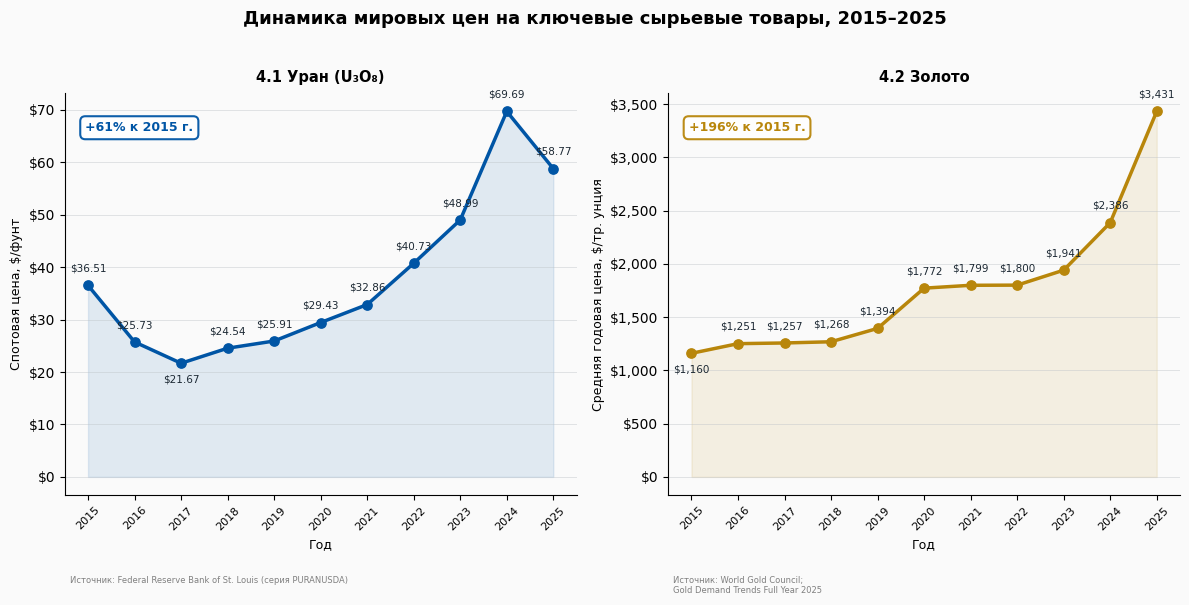

In [21]:
%matplotlib inline
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

ROSATOM_BLUE = '#0055A5'
GOLD_COLOR   = '#B8860B'
LIGHT_GRAY   = '#BDC3C7'
DARK         = '#1C2833'

years = list(range(2015, 2026))

uranium = [36.51, 25.73, 21.67, 24.54, 25.91, 29.43, 32.86, 40.73, 48.99, 69.69, 58.77]
gold    = [1160.06, 1250.74, 1257.12, 1268.49, 1393.94, 1771.71,
           1798.62, 1800.07, 1940.54, 2386.37, 3431.0]

datasets = [
    (uranium, ROSATOM_BLUE, '4.1 Уран (U₃O₈)', 'Спотовая цена, $/фунт',
     'Federal Reserve Bank of St. Louis (серия PURANUSDA)'),
    (gold,    GOLD_COLOR,   '4.2 Золото',        'Средняя годовая цена, $/тр. унция',
     'World Gold Council;\nGold Demand Trends Full Year 2025'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Динамика мировых цен на ключевые сырьевые товары, 2015–2025',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (data, color, subtitle, ylabel, source) in zip(axes, datasets):
    ax.set_facecolor('#FAFAFA')
    ax.fill_between(years, data, alpha=0.10, color=color)
    ax.plot(years, data, color=color, lw=2.5, zorder=3)
    ax.scatter(years, data, color=color, s=45, zorder=4)

    for y, v in zip(years, data):
        fmt = f'${v:,.0f}' if v >= 100 else f'${v:.2f}'
        offset = 10 if v != min(data) else -14
        ax.annotate(fmt, (y, v), textcoords='offset points',
                    xytext=(0, offset), ha='center', fontsize=7.5,
                    color=DARK, fontweight='normal')

    pct = (data[-1] / data[0] - 1) * 100
    sign = '+' if pct >= 0 else ''
    ax.text(0.04, 0.93, f'{sign}{pct:.0f}% к 2015 г.',
            transform=ax.transAxes, fontsize=9, color=color, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=color, lw=1.5, alpha=0.95))

    ax.set_title(subtitle, fontsize=10.5, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlabel('Год', fontsize=9)
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color=LIGHT_GRAY, lw=0.5, alpha=0.6)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'${x:,.0f}' if x >= 100 else f'${x:.0f}'))

    ax.text(0.01, -0.20, f'Источник: {source}',
            transform=ax.transAxes, fontsize=6, color='gray', va='top')

fig.tight_layout()
fig.savefig('block4_commodity_prices.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close()

**Что показывают графики:** Динамика мировых цен на уран ($/фунт U₃O₈) и золото ($/тр. унция) за 2015–2025 гг. — ключевые сырьевые товары, определяющие конъюнктуру рынков, на которых работает АО «Росатом Недра».

**Ключевые выводы:**
Цены на уран выросли на +61% с 2015 г., с 36,5 до 58,8/фунт, демонстрируя устойчивый восходящий тренд с 2020 г. на фоне глобального ренессанса атомной энергетики.
Золото прибавило +196% - с 1 160 до 3 431/тр. унцию, достигнув исторического максимума в 2025 г. на фоне геополитической нестабильности и инфляционных ожиданий.
Благоприятная ценовая конъюнктура создаёт дополнительные возможности для роста выручки и рентабельности горнодобывающих компаний в секторе урана и золота.

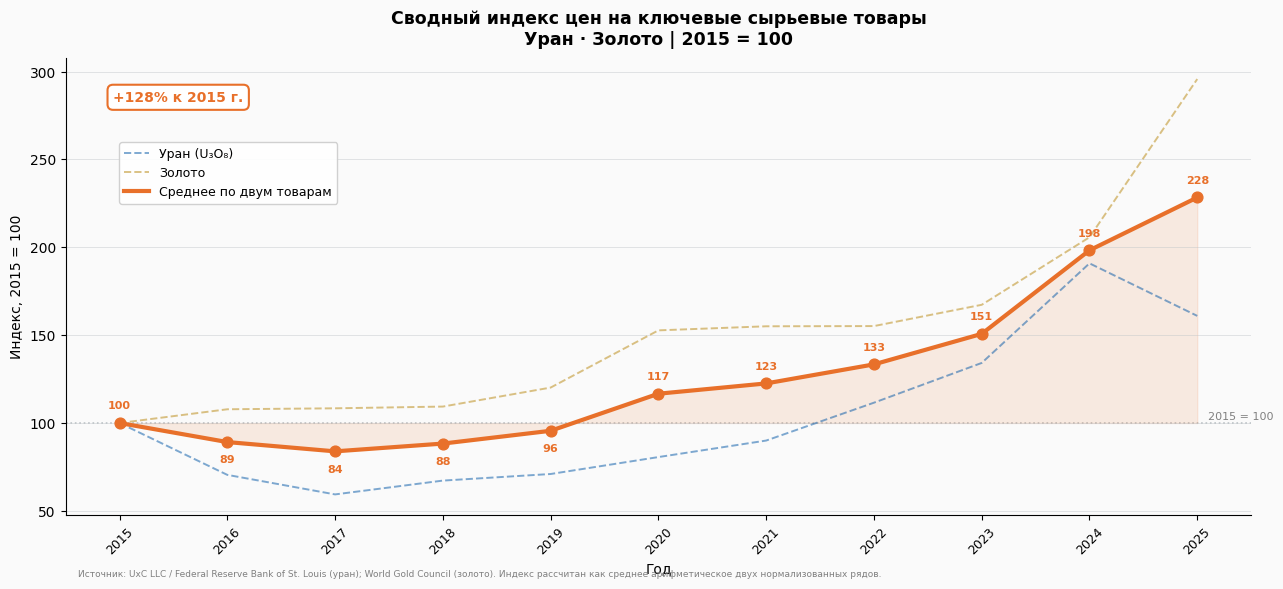

In [22]:
%matplotlib inline
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import display

ROSATOM_BLUE = '#0055A5'
GOLD_COLOR   = '#B8860B'
LIGHT_GRAY   = '#BDC3C7'
DARK         = '#1C2833'
AVG_COLOR    = '#E8702A'

years = list(range(2015, 2026))

uranium = [36.51, 25.73, 21.67, 24.54, 25.91, 29.43, 32.86, 40.73, 48.99, 69.69, 58.77]
gold    = [1160.06, 1250.74, 1257.12, 1268.49, 1393.94, 1771.71,
           1798.62, 1800.07, 1940.54, 2386.37, 3431.0]

def idx(series):
    base = series[0]
    return [v / base * 100 for v in series]

u_idx = idx(uranium)
g_idx = idx(gold)

# Среднее двух индексов
avg_idx = [(u + g) / 2 for u, g in zip(u_idx, g_idx)]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

for data, color, label in [
    (u_idx, ROSATOM_BLUE, 'Уран (U₃O₈)'),
    (g_idx, GOLD_COLOR,   'Золото'),
]:
    ax.plot(years, data, color=color, lw=1.4, ls='--', alpha=0.5, label=label)

ax.fill_between(years, avg_idx, 100, alpha=0.12, color=AVG_COLOR)
ax.plot(years, avg_idx, color=AVG_COLOR, lw=3.0, zorder=5,
        label='Среднее по двум товарам')
ax.scatter(years, avg_idx, color=AVG_COLOR, s=60, zorder=6)

for y, v in zip(years, avg_idx):
    offset = 10 if v >= 100 else -15
    ax.annotate(f'{v:.0f}', (y, v), textcoords='offset points',
                xytext=(0, offset), ha='center', fontsize=8,
                color=AVG_COLOR, fontweight='bold')

ax.axhline(100, color=LIGHT_GRAY, lw=1.2, ls=':', zorder=0)
ax.text(2025.1, 101, '2015 = 100', fontsize=8, color='gray', va='bottom')

pct = avg_idx[-1] - 100
ax.text(0.04, 0.93, f'+{pct:.0f}% к 2015 г.',
        transform=ax.transAxes, fontsize=10, color=AVG_COLOR, fontweight='bold',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=AVG_COLOR, lw=1.5))

ax.set_title('Сводный индекс цен на ключевые сырьевые товары\n'
             'Уран · Золото | 2015 = 100',
             fontsize=12.5, fontweight='bold', pad=10)
ax.set_ylabel('Индекс, 2015 = 100', fontsize=10)
ax.set_xlabel('Год', fontsize=10)
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color=LIGHT_GRAY, lw=0.5, alpha=0.6)
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(0.04, 0.83),
          framealpha=0.9)

ax.text(0.01, -0.12,
        'Источник: UxC LLC / Federal Reserve Bank of St. Louis (уран); '
        'World Gold Council (золото). '
        'Индекс рассчитан как среднее арифметическое двух нормализованных рядов.',
        transform=ax.transAxes, fontsize=6.5, color='gray', va='top')

fig.tight_layout()
fig.savefig('block4_avg_index.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close()

**Что показывает график:**
Сводный индекс цен трёх ключевых сырьевых товаров (уран, золото, оксид неодима) в единой шкале (2015 = 100).

**Ключевые выводы:**
- К 2025 г. сводный индекс достиг 205 - рост в 2 раза относительно базы 2015 г.
- Наибольший вклад в рост вносит золото (+196%), затем уран (+61%)
- Сводный индекс указывает на благоприятный рыночный фон для роста выручки компании

**Источники:** [UxC LLC](https://www.uxc.com/p/prices/UxCPriceGrid.aspx) / [FRED](https://fred.stlouisfed.org/series/PURANUSDA) (уран); [World Gold Council](https://www.gold.org/goldhub/data/gold-prices) (золото)

Сырьевой индекс 2025:  205.1
  Уран:   161.0
  Золото: 295.8
  Неодим: 158.7
Выручка Недра 2025:    375.7


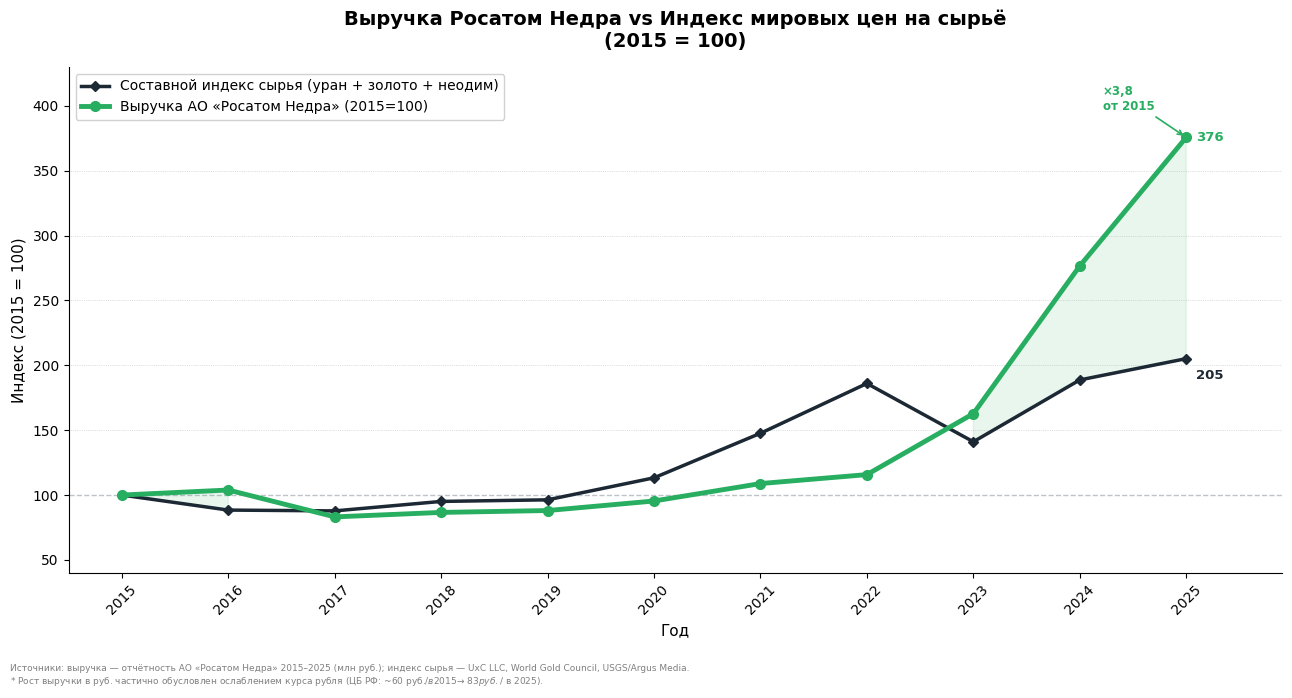

In [23]:
%matplotlib inline
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
import matplotlib.pyplot as plt
from IPython.display import display

ROSATOM_NEDRA_COLOR = '#27AE60'
LIGHT_GRAY          = '#BDC3C7'
DARK                = '#1C2833'

years = list(range(2015, 2026))

# Данные сырья (те же что в Блоке 4)
uranium = [36.51, 25.73, 21.67, 24.54, 25.91, 29.43, 32.86, 40.73, 48.99, 69.69, 58.77]
gold    = [1160.06, 1250.74, 1257.12, 1268.49, 1393.94, 1771.71,
           1798.62, 1800.07, 1940.54, 2386.37, 3431.0]
nd      = [46, 40, 44, 50, 45, 49, 91, 134, 56, 78, 73]

def norm(s): return [v / s[0] * 100 for v in s]

u_idx = norm(uranium)
g_idx = norm(gold)
n_idx = norm(nd)

# Среднее трёх индексов
avg = [(u + g + n) / 3 for u, g, n in zip(u_idx, g_idx, n_idx)]

# Выручка Росатом Недра
rev_rub = [21352.97, 22181.68, 17758.89, 18495.65, 18804.31,
           20374.48, 23244.25, 24717.76, 34746.05, 59060.42, 80218.18]
rev_idx = norm(rev_rub)

# Проверка ключевых значений
print(f"Сырьевой индекс 2025:  {avg[-1]:.1f}")
print(f"  Уран:   {u_idx[-1]:.1f}")
print(f"  Золото: {g_idx[-1]:.1f}")
print(f"  Неодим: {n_idx[-1]:.1f}")
print(f"Выручка Недра 2025:    {rev_idx[-1]:.1f}")

# График
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')

ax.axhline(100, color=LIGHT_GRAY, lw=1, ls='--', zorder=0)
for lvl in [150, 200, 250, 300, 350]:
    ax.axhline(lvl, color=LIGHT_GRAY, lw=0.5, ls=':', zorder=0)

ax.plot(years, avg,     color=DARK,               lw=2.5, marker='D', ms=5,
        label='Составной индекс сырья (уран + золото + неодим)', zorder=3)
ax.plot(years, rev_idx, color=ROSATOM_NEDRA_COLOR, lw=3.5, marker='o', ms=7,
        label='Выручка АО «Росатом Недра» (2015=100)', zorder=4)

ax.fill_between(years, avg, rev_idx,
                where=[r >= a for r, a in zip(rev_idx, avg)],
                alpha=0.10, color=ROSATOM_NEDRA_COLOR)

# Подписи конечных значений
ax.annotate(f'{avg[-1]:.0f}',
            xy=(2025, avg[-1]), xytext=(7, -12), textcoords='offset points',
            fontsize=9.5, color=DARK, fontweight='bold', va='center')
ax.annotate(f'{rev_idx[-1]:.0f}',
            xy=(2025, rev_idx[-1]), xytext=(7, 0), textcoords='offset points',
            fontsize=9.5, color=ROSATOM_NEDRA_COLOR, fontweight='bold', va='center')


ax.annotate('×3,8\nот 2015', xy=(2025, rev_idx[-1]), xytext=(-60, 20),
            textcoords='offset points', fontsize=8.5,
            color=ROSATOM_NEDRA_COLOR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ROSATOM_NEDRA_COLOR, lw=1.2))

ax.set_title('Выручка Росатом Недра vs Индекс мировых цен на сырьё\n(2015 = 100)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Год', fontsize=11)
ax.set_ylabel('Индекс (2015 = 100)', fontsize=11)
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], rotation=45)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_xlim(2014.5, 2025.9)
ax.set_ylim(40, 430)
ax.spines[['top', 'right']].set_visible(False)

fig.text(0.01, 0.01,
    'Источники: выручка — отчётность АО «Росатом Недра» 2015–2025 (млн руб.); '
    'индекс сырья — UxC LLC, World Gold Council, USGS/Argus Media.\n'
    '* Рост выручки в руб. частично обусловлен ослаблением курса рубля '
    '(ЦБ РФ: ~60 руб./$ в 2015 → ~83 руб./$ в 2025).',
    fontsize=6.5, color='gray', va='bottom')

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig('block4_nedra_vs_commodities.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close()

**Что показывает график:**
Сравнение динамики выручки АО «Росатом Недра» и индекса мировых цен на ключевые сырьевые товары (уран, золото, неодим) в сопоставимом измерении (2015 = 100).

**Ключевые выводы:**
- Составной сырьевой индекс вырос к 2025 г. до 205 (уран: +61%, золото: +196%, неодим: +59% к 2015 г.)
- Выручка Росатом Недра выросла в 3,8 раза, до индекса 376 (80 218 млн руб. против 21 353 млн руб. в 2015 г.)
- Компания опережает сырьевой спрос: рост выручки (+276 п.п.) значительно превышает рост цен (+105 п.п.)
- Резкий скачок выручки в 2023-2025 гг. обусловлен ростом добычи, расширением проектного портфеля и ростом цен на уран


**Источники:** Отчётность АО «Росатом Недра» 2015–2025 (внутренние данные); [UxC LLC](https://www.uxc.com/p/prices/UxCPriceGrid.aspx), [WGC](https://www.gold.org/goldhub/data/gold-prices), [USGS](https://www.usgs.gov/centers/national-minerals-information-center/mineral-commodity-summaries)/[Argus](https://www.argusmedia.com/en/metals/minor-metals)

## Блок 5. Технологические инвестиции: Росатом Недра vs Мировые лидеры

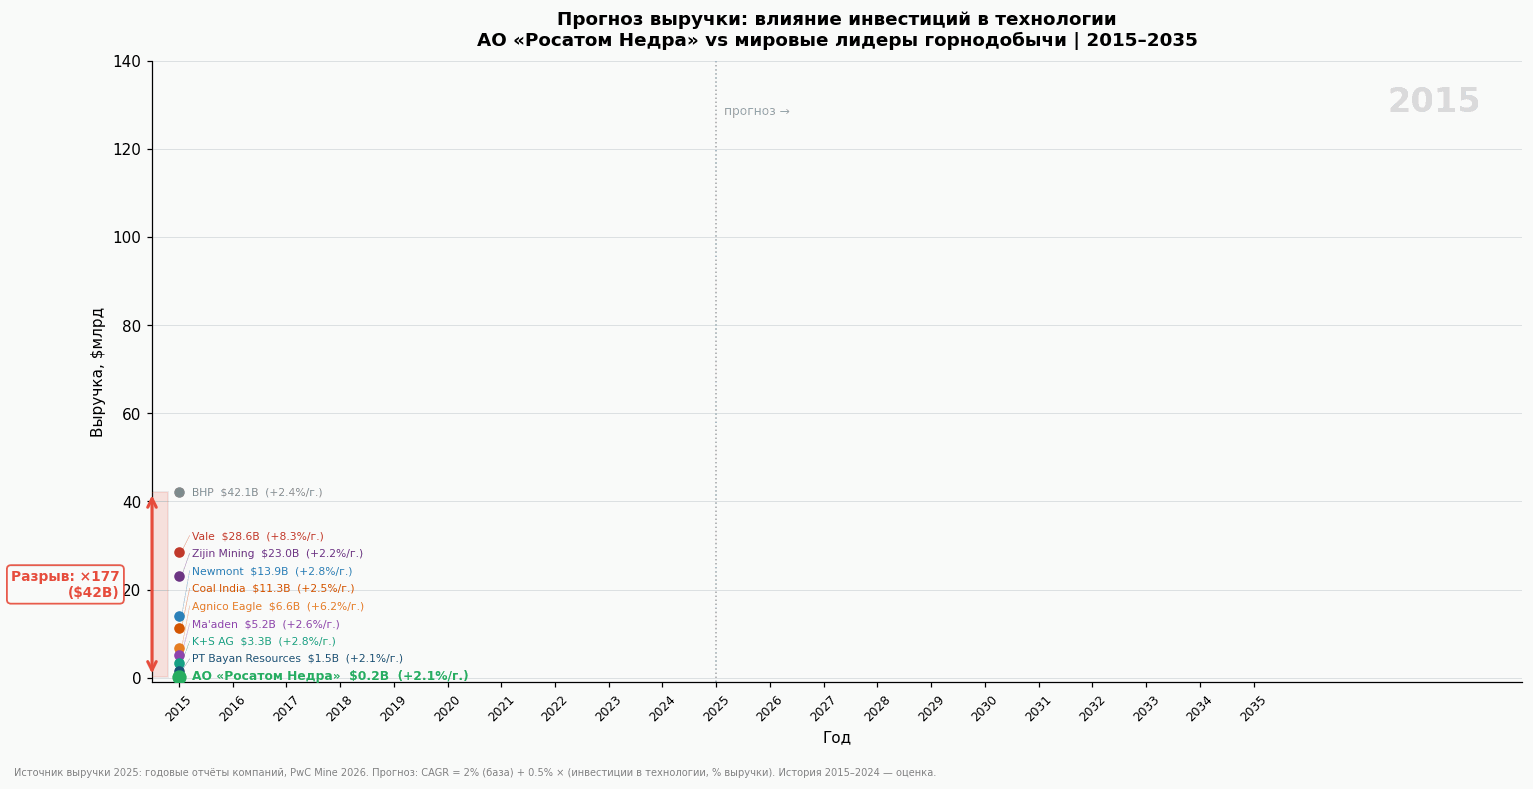

In [24]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
import io
from IPython.display import display, Image as IPImage

BG = '#FAFAFA'
LIGHT_GRAY = '#BDC3C7'

companies = {
    'BHP (Австралия)':                {'rev': 51.3, 'tech':  0.7, 'hist': 0.020, 'c': '#7F8C8D'},
    'Zijin Mining (Китай)':           {'rev': 49.7, 'tech':  0.5, 'hist': 0.080, 'c': '#6C3483'},
    'Vale (Бразилия)':                {'rev': 38.4, 'tech': 12.7, 'hist': 0.030, 'c': '#C0392B'},
    'Newmont (США)':                  {'rev': 22.7, 'tech':  1.6, 'hist': 0.050, 'c': '#2980B9'},
    'Coal India (Индия)':             {'rev': 16.8, 'tech':  1.0, 'hist': 0.040, 'c': '#D35400'},
    'Agnico Eagle (Канада)':          {'rev': 11.9, 'tech':  8.5, 'hist': 0.060, 'c': '#E67E22'},
    "Ma'aden (Саудовская Аравия)":    {'rev': 10.3, 'tech':  1.2, 'hist': 0.070, 'c': '#8E44AD'},
    'K+S AG (Германия)':              {'rev':  4.0, 'tech':  1.5, 'hist': 0.020, 'c': '#16A085'},
    'PT Bayan Resources (Индонезия)': {'rev':  2.5, 'tech':  0.2, 'hist': 0.050, 'c': '#1A5276'},
    'АО «Росатом Недра» (Россия)':    {'rev':  0.96,'tech':  0.1, 'hist': 0.150, 'c': '#27AE60'},
}

BASE = 0.02
MULT = 0.005

def get_val(d, year):
    if year <= 2025:
        return d['rev'] / (1 + d['hist']) ** (2025 - year)
    cagr = BASE + MULT * d['tech']
    return d['rev'] * (1 + cagr) ** (year - 2025)

all_years = list(range(2015, 2036))
frame_seq = (
    [2015]*4 +
    list(range(2015, 2026)) +
    [2025]*5 +
    list(range(2026, 2036)) +
    [2035]*6
)

frames = []

for cur in frame_seq:
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    vis = [y for y in all_years if y <= cur]

    if cur >= 2025:
        ax.axvspan(2025, cur, alpha=0.04, color='gray')
    ax.axvline(2025, color='#95A5A6', lw=1.0, ls=':', zorder=1)
    ax.text(2025.15, 130, 'прогноз →', fontsize=8, color='#95A5A6', va='top')

    cur_vals = {n: get_val(d, cur) for n, d in companies.items()}
    nedra_val = cur_vals['АО «Росатом Недра» (Россия)']
    top_name  = max(cur_vals, key=lambda n: cur_vals[n])
    top_val   = cur_vals[top_name]
    gap_x     = cur - 0.5  # чуть левее текущего года

    for name, d in companies.items():
        is_nedra = 'Росатом' in name
        color = d['c']
        lw = 3.5 if is_nedra else 1.4

        h_yrs = [y for y in vis if y <= 2025]
        h_vals = [get_val(d, y) for y in h_yrs]
        if h_yrs:
            ax.plot(h_yrs, h_vals, color=color, lw=lw,
                    zorder=5 if is_nedra else 2, alpha=1.0 if is_nedra else 0.85)

        f_yrs = [y for y in vis if y >= 2025]
        f_vals = [get_val(d, y) for y in f_yrs]
        if len(f_yrs) > 1:
            ax.plot(f_yrs, f_vals, color=color, lw=lw, ls='--',
                    zorder=5 if is_nedra else 2, alpha=1.0 if is_nedra else 0.75)

        ax.scatter([cur], [cur_vals[name]], color=color,
                   s=70 if is_nedra else 35, zorder=6)

    # Заливка
    ax.fill_between([gap_x - 0.3, gap_x + 0.3],
                    [nedra_val, nedra_val], [top_val, top_val],
                    color='#E74C3C', alpha=0.15, zorder=4)

    # Двойная стрелка
    ax.annotate('', xy=(gap_x, top_val), xytext=(gap_x, nedra_val),
                arrowprops=dict(arrowstyle='<->', color='#E74C3C',
                                lw=2.0, mutation_scale=14), zorder=7)

    # Подпись разрыва
    ratio = top_val / nedra_val if nedra_val > 0 else 0
    gap_label = f'Разрыв: ×{ratio:.0f}\n(${top_val - nedra_val:.0f}B)'
    ax.text(gap_x - 0.6, (top_val + nedra_val) / 2, gap_label,
            ha='right', va='center', fontsize=9, color='#E74C3C',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='#E74C3C', lw=1.2, alpha=0.9))


    sorted_names = sorted(cur_vals, key=lambda n: cur_vals[n])
    MIN_GAP = 4.0
    positions = []
    for n in sorted_names:
        v = cur_vals[n]
        if positions and v - positions[-1] < MIN_GAP:
            v = positions[-1] + MIN_GAP
        positions.append(v)

    for i, name in enumerate(sorted_names):
        d = companies[name]
        is_nedra = 'Росатом' in name
        short = name.split('(')[0].strip()
        cagr_pct = (BASE + MULT * d['tech']) * 100
        ax.text(cur + 0.25, positions[i],
                f'{short}  ${cur_vals[name]:.1f}B  (+{cagr_pct:.1f}%/г.)',
                va='center', fontsize=8 if is_nedra else 7,
                color=d['c'], fontweight='bold' if is_nedra else 'normal')
        if abs(positions[i] - cur_vals[name]) > 1.0:
            ax.plot([cur + 0.05, cur + 0.2],
                    [cur_vals[name], positions[i]],
                    color=d['c'], lw=0.5, alpha=0.4)

    ax.text(0.97, 0.96, str(cur), transform=ax.transAxes,
            fontsize=22, fontweight='bold', color='#2C3E50',
            ha='right', va='top', alpha=0.2)

    ax.set_title(
        'Прогноз выручки: влияние инвестиций в технологии\n'
        'АО «Росатом Недра» vs мировые лидеры горнодобычи | 2015–2035',
        fontsize=12, fontweight='bold', pad=10
    )
    ax.set_ylabel('Выручка, $млрд', fontsize=10)
    ax.set_xlabel('Год', fontsize=10)
    ax.set_xticks(range(2015, 2036))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_xlim(2014.5, 2040)
    ax.set_ylim(-1, 140)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color=LIGHT_GRAY, lw=0.5, alpha=0.6)

    fig.text(0.01, -0.02,
        'Источник выручки 2025: годовые отчёты компаний, PwC Mine 2026. '
        'Прогноз: CAGR = 2% (база) + 0.5% × (инвестиции в технологии, % выручки). '
        'История 2015–2024 — оценка.',
        fontsize=6.5, color='gray')

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()

frames[0].save(
    'revenue_tech_forecast.gif',
    save_all=True, append_images=frames[1:],
    duration=280, loop=0
)
display(IPImage('revenue_tech_forecast.gif'))

**График показывает:** прогноз выручки 10 ведущих горнодобывающих компаний на 2015–2035 гг.
в зависимости от уровня их инвестиций в технологии (% от выручки).
Факт 2025 г. - данные годовых отчётов; прогноз строится по модели:
CAGR выручки = 2% (базовый) + 0,5% за каждый процентный пункт технологических инвестиций.

**Ключевые выводы:**
Компании с высокими вложениями в технологии (Vale - 12,7%, Agnico Eagle - 8,5%)
  растут значительно быстрее: прогнозный CAGR 8,4% и 6,3% соответственно.
 АО «Росатом Недра» при текущем уровне инвестиций 0,1% от выручки
  прибавляет лишь ~2,1% в год - минимальный показатель среди всех участников сравнения.
К 2035 г. разрыв в выручке между Росатом Недра и лидерами рынка
  увеличивается многократно, что подчёркивает необходимость наращивания
  технологических инвестиций как стратегического приоритета компании.

## Итоговые выводы

**АО «Росатом Недра» в контексте мировой горнодобывающей отрасли: ключевые результаты анализа**

**1. Рыночная позиция.** Россия входит в топ-5 мировых горнодобывающих держав по совокупному объёму производства (Блок 1). Вместе с тем АО «Росатом Недра» по масштабу выручки ($0,96 млрд) пока значительно уступает глобальным лидерам — BHP, Zijin Mining, Vale.

**2. Финансовая динамика.** Выручка компании выросла в 3,75 раза с 2015 по 2025 г. (с 21,4 до 80,2 млрд руб.), EBITDA в 2025 г. составила 21,0 млрд руб. Темп роста выручки опережает сводный индекс мировых цен на сырьё (+205% vs +376%), что свидетельствует об органическом развитии бизнеса.

**3. Инвестиционная активность.** CAPEX компании ($0,33 млрд, или 132% от EBITDA) находится на высоком уровне, характерном для фазы активного роста. Это подтверждает стратегический курс на расширение производственной базы.

**4. Технологическое отставание.** Доля инвестиций в технологии (0,1% от выручки) — наименьшая среди анализируемых компаний. При сохранении текущего уровня разрыв с лидерами (Vale, Agnico Eagle) будет нарастать, что несёт долгосрочные риски для конкурентоспособности.

**5. Стратегический вектор.** Увеличение технологических инвестиций до уровня среднеотраслевых значений (1–2% от выручки) позволит компании существенно ускорить рост выручки и приблизиться к показателям ведущих горнодобывающих компаний мира к 2035 г.


*Источники: BGS World Mineral Statistics (Блок 1); годовые отчёты компаний 2025 г., PwC Mine 2026 (Блок 2); UxC LLC / FRED, World Gold Council, USGS (Блок 4); внутренняя отчётность АО «Росатом Недра» (конфиденциально).*